# Lecture 21 - (12/05/2026)

Today's Topics:

- tSNE Algorithm

## t-Distributed Stochastic Neighbour Embedding

t-Distributed Stochastic Neighbour Embedding (t-SNE) is a popular and powerful technique used for the visualization of high-dimensional data. It is widely employed in machine learning and data science to project data from a high-dimensional space into two or three dimensions, making it easier to detect patterns, clusters, and relationships among data points.

t-SNE is a non-linear dimensionality reduction algorithm specifically designed for visualizing high-dimensional data. Unlike linear techniques such as Naive Bayes, t-SNE excels at capturing the local structure of data, making it particularly useful for identifying clusters and subclusters in complex datasets.

![image](https://biocellgen-public.svi.edu.au/mage_2020_marker-gene-benchmarking/figure/pbmc3k-data.Rmd/plot-tsne-after-annotation-1.png)

tSNE excels at:

- Dimensionality Reduction: t-SNE reduces the dimensionality of data while preserving the relationships between nearby points. This makes it ideal for visualizing high-dimensional data in 2D or 3D plots.

- Non-Linear Mapping: t-SNE focuses on maintaining the local structure of the data, ensuring that similar data points remain close together in the lower-dimensional space, while less similar points are mapped further apart.

- Capturing Complex Patterns: t-SNE is particularly effective in datasets where the relationships between data points are complex and non-linear, such as in image recognition, text mining, and biological data analysis.

Some use cases for tSNE include:

- Image and Video Analysis: t-SNE is often applied to visualize features extracted from images and videos, helping researchers and practitioners identify patterns and group similar objects.

- Natural Language Processing (NLP): In NLP, t-SNE can be used to visualize word embeddings or document similarities, providing insights into the relationships between words or topics.

- Genomics and Bioinformatics: t-SNE is a valuable tool for visualizing high-dimensional biological data, such as gene expression profiles, to uncover hidden patterns or groupings within the data.

- Document Clustering: In natural language processing, t-SNE can group similar documents together, facilitating tasks like topic modeling or information retrieval.


and some of the advantages to tSNE include:

- Effective Visualization: t-SNE provides an intuitive and visually interpretable representation of high-dimensional data, making it easier to understand and communicate complex patterns.

- Flexibility: t-SNE is flexible in its ability to reveal both global and local structures in the data, depending on how it is parameterized, allowing for tailored analysis based on specific needs.

- Preservation of Local Structure: By focusing on maintaining the local relationships between data points, t-SNE ensures that similar points are grouped together, enhancing the detection of clusters.

- Versatility Across Domains: t-SNE's ability to handle complex and high-dimensional data makes it applicable across various domains, from computer vision to genomics.

### tSNE Theory

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique that has become a standard tool for visualizing high-dimensional data. Developed by Laurens van der Maaten and Geoffrey Hinton in 2008, t-SNE is particularly effective at revealing the structure of data by reducing its dimensions to two or three, which can then be easily visualized.

High-dimensional datasets are often difficult to interpret because the relationships between data points are not easily visualized. Dimensionality reduction techniques, like PCA, project data into lower dimensions, but they may not capture the non-linear relationships inherent in the data. t-SNE addresses this by focusing on preserving the local structure of the data, which is crucial for identifying clusters and patterns.

t-SNE builds on the idea that similar points in high-dimensional space should remain close in the lower-dimensional representation, while dissimilar points should be far apart. This is achieved through the following steps:



#### Pairwise Similarities in High Dimensions

Given a high-dimensional dataset, t-SNE starts by converting the pairwise Euclidean distances between data points into conditional probabilities that represent similarities. For two data points $x_i$ and $x_j$, the simmilarity of $x_j$ and $x_i$ is given by:

$$ P_{j|i} = \frac{exp(-||x_i - x_j ||^2 / 2\sigma_i^2)}{\sum_{k\not = i} exp(-||x_i - x_k||^2 / 2 \sigma_i^2)}$$

Where:

- $x_ - $x_j^2$ is the squared euclidian distance between points $x_i$ and $x_j$.
- $\sigma_i$ is a gaussian kernel bandwidth parameter specific to point $x_i$

The joint probability distribution for the pair $(x_i, x_j)$ is defined as:

$$ P_{ij} = \frac{P_{j|i}+P_{i|j}}{2n}$$

where n is the total number of points in the dataset.

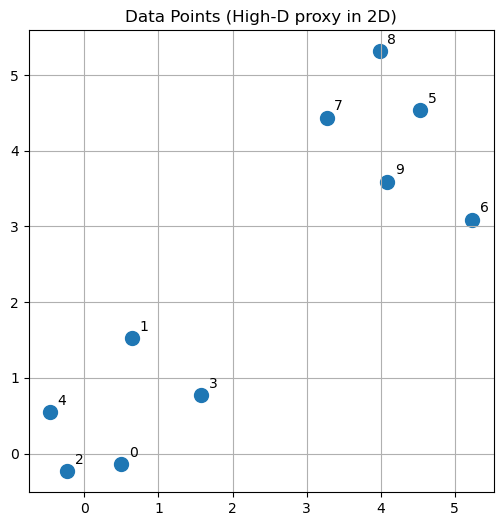

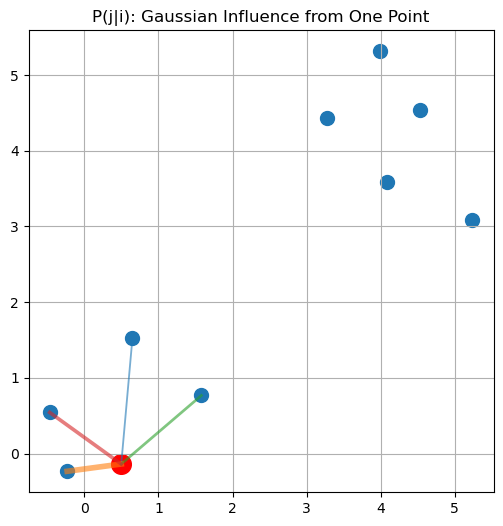

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Fake "high-dimensional" data (use 2D for visualization)
# -----------------------------
np.random.seed(42)

n = 10
X = np.vstack([
    np.random.randn(n//2, 2) + np.array([0, 0]),
    np.random.randn(n//2, 2) + np.array([5, 5])
])

# -----------------------------
# 2. Gaussian similarity function (P_{j|i})
# -----------------------------
def compute_pij(X, sigma=1.0):
    n = len(X)
    P = np.zeros((n, n))

    for i in range(n):
        dists = np.sum((X[i] - X)**2, axis=1)
        weights = np.exp(-dists / (2 * sigma**2))
        weights[i] = 0  # exclude self

        P[i] = weights / np.sum(weights)

    return P

P = compute_pij(X, sigma=1.0)

# -----------------------------
# 3. Visualize dataset
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=100)

for i in range(n):
    plt.text(X[i, 0] + 0.1, X[i, 1] + 0.1, str(i))

plt.title("Data Points (High-D proxy in 2D)")
plt.grid()
plt.show()

# -----------------------------
# 4. Show Gaussian influence of ONE point
# -----------------------------
i = 0  # pick a reference point

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=100)

# highlight center point
plt.scatter(X[i, 0], X[i, 1], s=200, color='red')

# draw influence (line thickness = probability)
for j in range(n):
    if i != j:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]],
            linewidth=P[i, j] * 10,
            alpha=0.6
        )

plt.title("P(j|i): Gaussian Influence from One Point")
plt.grid()
plt.show()



#### Pairwise similarities in low dimension

In the lower-dimensional space, t-SNE aims to create a similar probability distribution for the points. For the low-dimensional counterparts $y_i$ and $y_j$ of the original points $x_i$ and $x_j$, the similarity is modeled using a Student's t-distribution with one degree of freedom (which has heavier tails than a Gaussian distribution):

$$ Q_{ij} = \frac{(1+||y_i-y_j||^2)^{-1}}{\sum_{k\not= l} (1+||y_k - y_l||^2)^{-1}}$$

The use of the t-distribution instead of a Gaussian distribution helps t-SNE to place dissimilar points further apart in the lower-dimensional space, reducing the "crowding problem" common in dimensionality reduction.

#### Kullback-Leibler Divergence

To measure how well the lower-dimensional distribution $Q_{ij}$ matches the high-dimensional distribution $P_{ij}$, t-SNE uses the Kullback-Leibler (KL) divergence:

$$ KL(P||Q) = \sum_{i \not= j} P_{ij} \log \frac{P_{ij}}{Q_{ij}}$$

t-SNE attempts to minimize this divergence, adjusting the positions of the points in the low-dimensional space to make the two distributions as similar as possible.

## tSNE MNIST

PyTorch is widely used for its flexibility and ease of use in building and training deep learning models. While PyTorch does not include a built-in t-SNE function, we can manually implement the key components of t-SNE to visualize high-dimensional datasets effectively.

In [6]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

We will use the MNIST dataset of handwritten digits for our example.

In [14]:
# Load the digits dataset
digits = load_digits()

X = digits.data
labels = digits.target

# Standardize
X = StandardScaler().fit_transform(X)

# Tensor
X = torch.tensor(X, dtype=torch.float32)

- `StandardScaler`: Standardizes the data for better performance in the t-SNE algorithm.
- `torch.tensor`: Converts the NumPy array into a PyTorch tensor.


Step 1: Compute pairwise distances

In [30]:
def pairwise_distances(X):

    x2 = (X**2).sum(1, keepdim=True)

    dist = x2 + x2.t() - 2 * torch.mm(X, X.t())

    dist = torch.clamp(dist, min=0.0)

    return dist

- `pairwise_distances`: Computes squared Euclidean distances between all points in the dataset.


Step 2: Compute high dimension similarities

In [32]:
def compute_P(X, sigma=2.0):
    distances = pairwise_distances(X)

    # Gaussian kernel
    P = torch.exp(-distances / (2 * sigma**2))

    # Remove self similarities
    P.fill_diagonal_(0)

    # Symmetrize
    P = (P + P.T) / 2

    # Normalize
    P = P / torch.sum(P)

    # Stability
    P = torch.clamp(P, min=1e-12)

    return P

P = compute_P(X_tensor)

- `joint_probabilities`: Applies a Gaussian kernel to convert distances into probabilities.

Step 3: Initialize the low-dimensional map

In [33]:
# Initialize low-dimensional map
n = X.shape[0]

Y = torch.randn(n, 2, requires_grad=True)

# Lower LR is VERY important
optimizer = optim.Adam([Y], lr=5)

In [34]:
def compute_Q(Y):
    distances = pairwise_distances(Y)

    # Student-t kernel 
    numerator = 1 / (1 + distances)

    # remove diagonal
    numerator.fill_diagonal_(0)

    Q = numerator / torch.sum(numerator)

    Q = torch.clamp(Q, min=1e-12)

    return Q


- `torch.randn`: Initializes the low-dimensional map with random values.


Step 4: Optimize the t-SNE objective function

Finally, we optimize the t-SNE objective function using gradient descent.

In [35]:
def tsne_step():
    optimizer.zero_grad()

    Q = compute_Q(Y)

    # KL divergence
    loss = torch.sum(P * torch.log(P / Q))

    loss.backward()

    optimizer.step()

    return loss.item()

In [22]:
optimizer = optim.Adam([Y], lr=5)

def tsne_step():
    optimizer.zero_grad()

    low_dim_distances = pairwise_distances(Y)
    Q = low_dim_Q(Y)

    kl_divergence = torch.sum(P * torch.log(P / Q))
    kl_divergence.backward()

    optimizer.step()
    return kl_divergence

# Perform optimization for a set number of iterations
for i in range(5000):
    loss = tsne_step()
    if i % 500 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")

Iteration 0, Loss: 3.8005051612854004
Iteration 500, Loss: 1.4876536130905151
Iteration 1000, Loss: 1.1558479070663452
Iteration 1500, Loss: 1.4753985404968262
Iteration 2000, Loss: 0.9375907778739929
Iteration 2500, Loss: 0.8637746572494507
Iteration 3000, Loss: 0.9502357840538025
Iteration 3500, Loss: 0.7608603835105896
Iteration 4000, Loss: 1.3499720096588135
Iteration 4500, Loss: 0.7140405178070068


- `tsne_step`: Computes the Kullback-Leibler divergence and updates the low-dimensional map using gradient descent.


Step 5: Visualize the results

In [36]:
losses = []

for i in range(1000):

    loss = tsne_step()

    losses.append(loss)

    if i % 100 == 0:
        print(f"Iteration {i}, Loss = {loss:.4f}")

Iteration 0, Loss = 3.4544
Iteration 100, Loss = 2.9475
Iteration 200, Loss = 2.7776
Iteration 300, Loss = 2.7275
Iteration 400, Loss = 2.6890
Iteration 500, Loss = 2.6597
Iteration 600, Loss = 2.6619
Iteration 700, Loss = 2.6186
Iteration 800, Loss = 2.5973
Iteration 900, Loss = 2.5836


/tmp/ipykernel_2115/1510429257.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


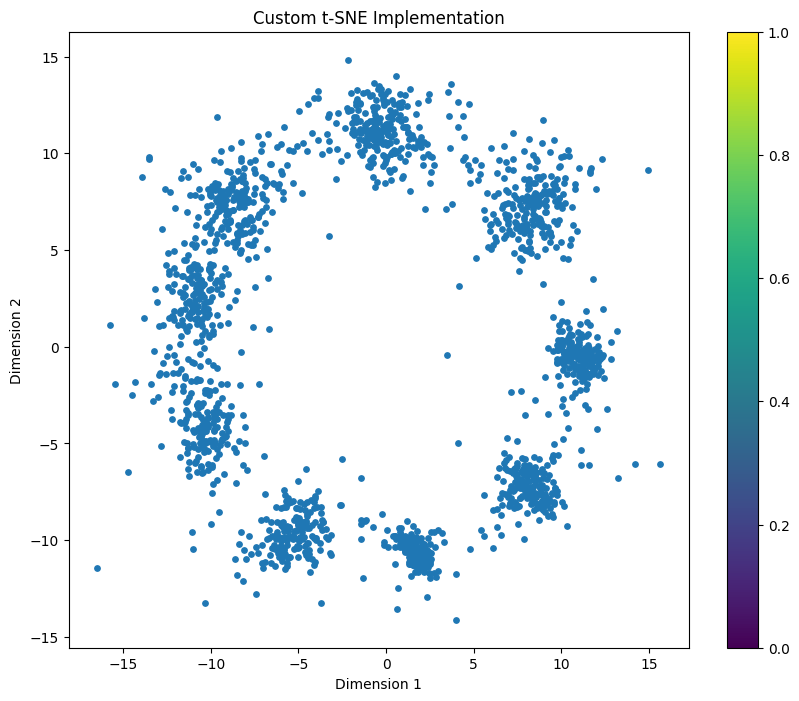

In [39]:
Y_np = Y.detach().numpy()

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    Y_np[:, 0],
    Y_np[:, 1],
    cmap="tab10",
    s=15
)

plt.colorbar(scatter)

plt.title("t-SNE Implementation")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()